# CS273P Final Project — Demo Notebook
## Multi-Task Learning for Predictive Maintenance

This notebook demonstrates the full pipeline:
1. Load and inspect the dataset
2. Load the best trained checkpoint
3. Run inference on the test set
4. Visualize results (loss curves, confusion matrix)
5. Run inference on a custom input

> **Prerequisites:** Run `python src/train.py` from the project root before running this notebook.

## 0. Setup

In [1]:
import sys
import os

PROJECT_ROOT = os.path.abspath(os.path.join(os.getcwd(), '..'))
sys.path.insert(0, os.path.join(PROJECT_ROOT, 'src'))
os.chdir(PROJECT_ROOT)

import torch
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

from dataset  import load_data, get_dataloaders
from model    import MTLModel, MTLLoss, count_parameters
from evaluate import evaluate, compute_metrics, print_report, plot_confusion_matrix
from utils    import set_seed, get_device

set_seed(42)
device = get_device()
print(f'Device: {device}')
print(f'PyTorch version: {torch.__version__}')

Device: mps
PyTorch version: 2.10.0


## 1. Dataset Overview

In [2]:
DATA_PATH = os.path.join('data', 'ai4i2020.csv')
df = pd.read_csv(DATA_PATH)
print(f'Dataset shape: {df.shape}')
df.head()

Dataset shape: (10000, 14)


,UDI,Product ID,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure,TWF,HDF,PWF,OSF,RNF
0,1,M14860,M,298.1,308.6,1551,42.8,0,0,0,0,0,0,0
1,2,L47181,L,298.2,308.7,1408,46.3,3,0,0,0,0,0,0
2,3,L47182,L,298.1,308.5,1498,49.4,5,0,0,0,0,0,0
3,4,L47183,L,298.2,308.6,1433,39.5,7,0,0,0,0,0,0
4,5,L47184,L,298.2,308.7,1408,40.0,9,0,0,0,0,0,0


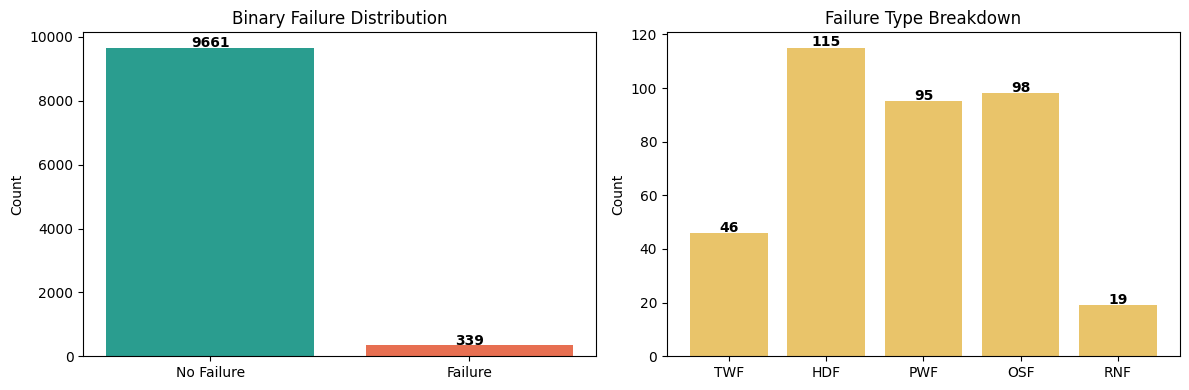

Overall failure rate: 3.4%


In [3]:
failure_cols = ['TWF', 'HDF', 'PWF', 'OSF', 'RNF']
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

counts = df['Machine failure'].value_counts()
axes[0].bar(['No Failure', 'Failure'], counts.values, color=['#2A9D8F', '#E76F51'])
axes[0].set_title('Binary Failure Distribution')
axes[0].set_ylabel('Count')
for i, v in enumerate(counts.values):
    axes[0].text(i, v + 20, str(v), ha='center', fontweight='bold')

type_counts = [df[col].sum() for col in failure_cols]
axes[1].bar(failure_cols, type_counts, color='#E9C46A')
axes[1].set_title('Failure Type Breakdown')
axes[1].set_ylabel('Count')
for i, v in enumerate(type_counts):
    axes[1].text(i, v + 0.5, str(v), ha='center', fontweight='bold')

plt.tight_layout()
plt.show()
print(f'Overall failure rate: {df["Machine failure"].mean()*100:.1f}%')

## 2. Load Data + Model

In [4]:
train_ds, val_ds, test_ds, scaler, w_bin, w_type = load_data(DATA_PATH)
train_loader, val_loader, test_loader = get_dataloaders(train_ds, val_ds, test_ds, batch_size=64)
print(f'Train: {len(train_ds)} | Val: {len(val_ds)} | Test: {len(test_ds)}')

Train: 7000 | Val: 1500 | Test: 1500


In [5]:
CHECKPOINT = os.path.join('checkpoints', 'best_model.pt')

if not os.path.exists(CHECKPOINT):
    raise FileNotFoundError(
        f'Checkpoint not found at {CHECKPOINT}.\n'
        'Please run `python src/train.py` from the project root first.'
    )

model = MTLModel().to(device)
checkpoint = torch.load(CHECKPOINT, map_location=device)
model.load_state_dict(checkpoint['model_state_dict'])

print(f'Loaded checkpoint from epoch {checkpoint["epoch"]}')
print(f'Trainable parameters: {count_parameters(model):,}')
print(f'Val metrics at save time: {checkpoint["metrics"]}')

Loaded checkpoint from epoch 21
Trainable parameters: 64,295
Val metrics at save time: {'binary_accuracy': 0.9013333333333333, 'binary_f1': 0.3884297520661157, 'binary_precision': 0.24607329842931938, 'binary_recall': 0.9215686274509803, 'binary_roc_auc': 0.9110948727317013, 'type_accuracy': 0.854, 'type_f1_macro': 0.36680509335471795, 'type_f1_weighted': 0.8996019210090791, 'type_precision_macro': 0.3006966375590885, 'type_recall_macro': 0.7682201055657383}


## 3. Test Set Evaluation

In [6]:
loss_fn = MTLLoss(alpha=0.5, binary_pos_weight=w_bin.to(device), type_class_weights=w_type.to(device))

test_loss, bin_preds, bin_targets, type_preds, type_targets = evaluate(
    model, test_loader, loss_fn, device
)
metrics = compute_metrics(bin_preds, bin_targets, type_preds, type_targets)

print(f'Test Loss: {test_loss:.4f}')
print_report(bin_preds, bin_targets, type_preds, type_targets)

Test Loss: 0.3988

--- Binary Failure Classification ---
              precision    recall  f1-score   support

  No Failure       1.00      0.89      0.94      1449
     Failure       0.23      0.92      0.37        51

    accuracy                           0.90      1500
   macro avg       0.62      0.91      0.66      1500
weighted avg       0.97      0.90      0.92      1500

--- Failure Type Classification (6-class) ---
              precision    recall  f1-score   support

  No Failure       1.00      0.85      0.92      1447
         TWF       0.06      0.86      0.11         7
         HDF       0.23      0.82      0.35        17
         PWF       0.23      0.92      0.37        12
         OSF       0.27      1.00      0.42        15
         RNF       0.00      0.00      0.00         2

    accuracy                           0.85      1500
   macro avg       0.30      0.74      0.36      1500
weighted avg       0.97      0.85      0.90      1500



In [7]:
metrics_df = pd.DataFrame({
    'Metric': list(metrics.keys()),
    'Value':  [round(v, 4) for v in metrics.values()]
})
metrics_df

,Metric,Value
0,binary_accuracy,0.8953
1,binary_f1,0.3745
2,binary_precision,0.2350
3,binary_recall,0.9216
4,binary_roc_auc,0.9080
5,type_accuracy,0.8487
6,type_f1_macro,0.3623
7,type_f1_weighted,0.8960
8,type_precision_macro,0.2971
9,type_recall_macro,0.7409


## 4. Visualizations

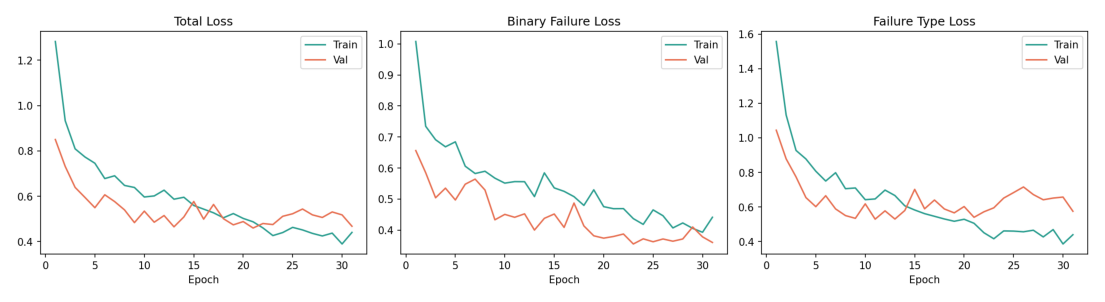

In [8]:
loss_curve_path = os.path.join('results', 'loss_curves.png')
if os.path.exists(loss_curve_path):
    img = mpimg.imread(loss_curve_path)
    plt.figure(figsize=(14, 4))
    plt.imshow(img)
    plt.axis('off')
    plt.show()
else:
    print('Loss curves not found — run train.py first.')

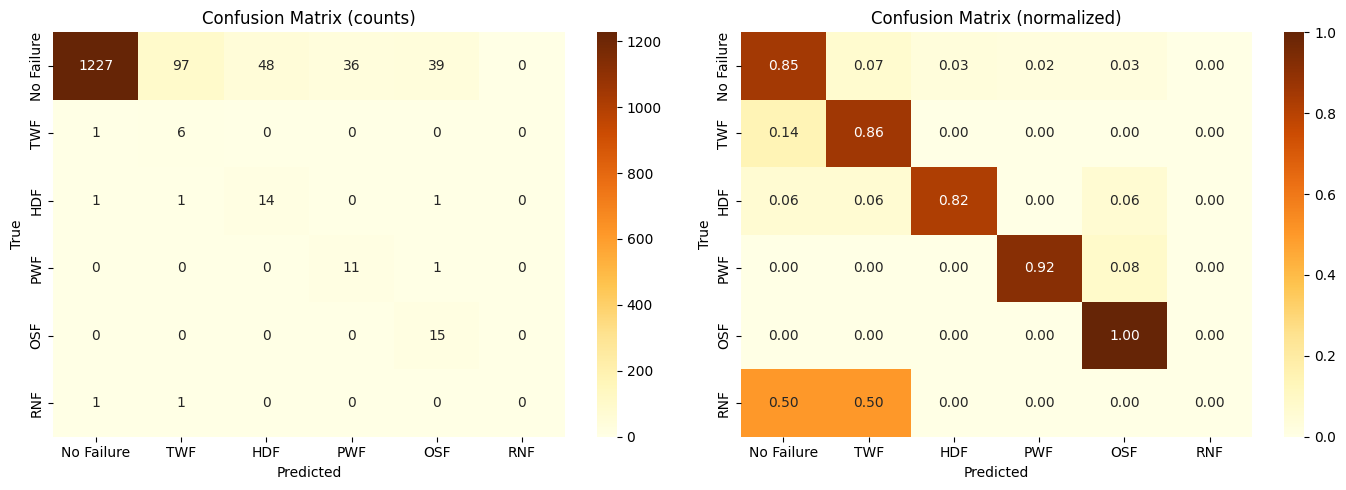

In [9]:
plot_confusion_matrix(type_preds, type_targets)

## 5. Custom Single-Sample Inference

Run the model on a hand-crafted machine reading. Edit the values in Example 3 to try your own.

In [10]:
FAILURE_TYPE_NAMES = ['No Failure', 'TWF', 'HDF', 'PWF', 'OSF', 'RNF']
TYPE_MAP = {'L': 0, 'M': 1, 'H': 2}

def predict_single(air_temp, process_temp, rot_speed, torque, tool_wear, machine_type='M'):
    continuous = np.array([[air_temp, process_temp, rot_speed, torque, tool_wear]], dtype=np.float32)
    continuous_scaled = scaler.transform(continuous)
    type_enc = np.array([[TYPE_MAP[machine_type]]], dtype=np.float32)
    features = np.concatenate([continuous_scaled, type_enc], axis=1)

    x = torch.tensor(features, dtype=torch.float32).to(device)
    model.eval()
    with torch.no_grad():
        bin_logit, type_logits = model(x)

    failure_prob  = torch.sigmoid(bin_logit).item()
    type_probs    = torch.softmax(type_logits, dim=1).squeeze().cpu().numpy()
    type_pred_idx = int(type_probs.argmax())

    return {
        'failure_probability': round(failure_prob, 4),
        'binary_prediction':   'FAILURE' if failure_prob >= 0.5 else 'No Failure',
        'predicted_type':      FAILURE_TYPE_NAMES[type_pred_idx],
        'type_probabilities':  {name: round(float(p), 4)
                                for name, p in zip(FAILURE_TYPE_NAMES, type_probs)},
    }

In [11]:
# Example 1: Normal operating conditions
result = predict_single(
    air_temp=298.1, process_temp=308.6,
    rot_speed=1551, torque=42.8, tool_wear=0,
    machine_type='M'
)
print('--- Normal operating conditions ---')
for k, v in result.items():
    print(f'  {k}: {v}')

--- Normal operating conditions ---
  failure_probability: 0.0007
  binary_prediction: No Failure
  predicted_type: No Failure
  type_probabilities: {'No Failure': 0.9997, 'TWF': 0.0, 'HDF': 0.0, 'PWF': 0.0, 'OSF': 0.0, 'RNF': 0.0003}


In [12]:
# Example 2: High torque + high tool wear — likely failure
result = predict_single(
    air_temp=302.5, process_temp=313.0,
    rot_speed=1200, torque=68.0, tool_wear=220,
    machine_type='L'
)
print('--- High stress conditions ---')
for k, v in result.items():
    print(f'  {k}: {v}')

--- High stress conditions ---
  failure_probability: 0.9999
  binary_prediction: FAILURE
  predicted_type: OSF
  type_probabilities: {'No Failure': 0.0, 'TWF': 0.0, 'HDF': 0.0, 'PWF': 0.0006, 'OSF': 0.9993, 'RNF': 0.0}


In [13]:
# Example 3: Edit these values and re-run!
result = predict_single(
    air_temp=300.0,
    process_temp=310.0,
    rot_speed=1400,
    torque=50.0,
    tool_wear=100,
    machine_type='H'
)
print('--- Custom input ---')
for k, v in result.items():
    print(f'  {k}: {v}')

--- Custom input ---
  failure_probability: 0.0704
  binary_prediction: No Failure
  predicted_type: No Failure
  type_probabilities: {'No Failure': 0.7085, 'TWF': 0.011, 'HDF': 0.0048, 'PWF': 0.0019, 'OSF': 0.0003, 'RNF': 0.2734}
